In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


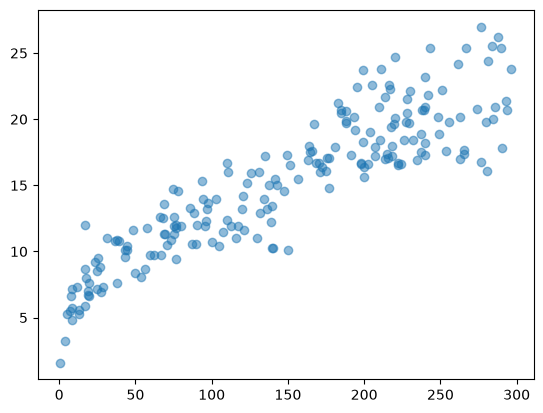

In [3]:
df = pd.read_csv("advertising.csv")

x = df['TV']
y = df['Sales']

plt.scatter(x, y, alpha=0.5)


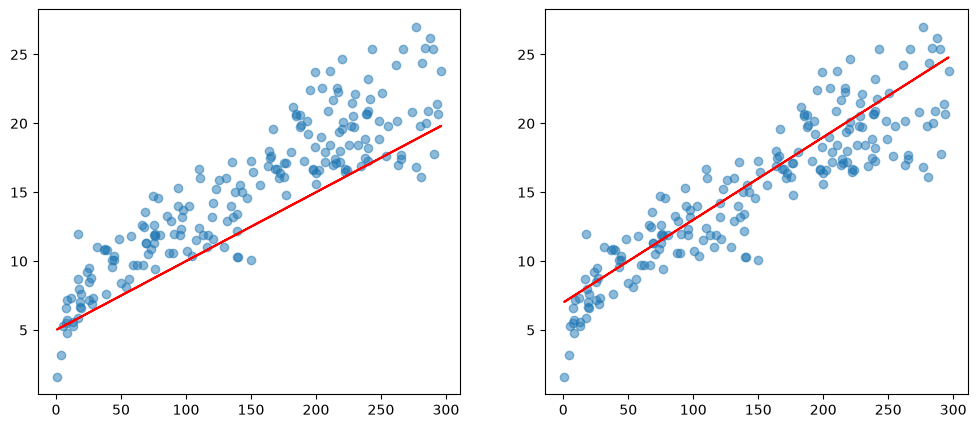

In [4]:
b0_1 = 5
b1_1 = .05
y_pred_1 = b0_1 + b1_1 * x

b0_2 = 7
b1_2 = .06
y_pred_2 = b0_2 + b1_2 * x

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].scatter(x, y, alpha=0.5)
axs[0].plot(x, y_pred_1, color='red')

axs[1].scatter(x, y, alpha=0.5)
axs[1].plot(x, y_pred_2, color='red')

In [10]:
# calculando absolute residual para cada observação:

def residual(y_true, y_pred):
    return np.abs(y_true - y_pred)

print(residual(y, y_pred_1).head())
print(residual(y, y_pred_2).head())

# calculando o MSE para nossa loss function

def mse(y_true, y_pred):
    """
    Função que calcula o erro quadrático médio (MSE) entre os valores reais e previstos.

    Parâmetros:
    y_true: série pandas contendo os valores reais.
    y_pred: série pandas contendo os valores previstos.

    Retorna:
    O valor do MSE.
    """
    return (residual(y_true, y_pred) ** 2).mean()

print(mse(y, y_pred_1))

0    5.595
1    3.175
2    6.140
3    3.925
4    3.860
dtype: float64
0    1.294
1    0.730
2    3.968
3    0.410
4    0.052
dtype: float64
13.156134874999998


In [ ]:
# como estamos falando de regressão linear, vamos calcular o loss function de b0 e b1
# mesmo resultado que a de cima

def loss(x, beta0, beta1, y_true):
    
    return (residual(y_true, (beta0 + beta1 * x)) ** 2).mean()

loss(x, 5, .05, y)

# como minimizar isso?
# FITTING / TRAINING the model!
from sklearn.linear_model import LinearRegression

xdf = df[['TV']]

reg = LinearRegression()
reg.fit(X=xdf, y=y)

print(reg.coef_)
print(reg.intercept_)

[0.05546477]
6.974821488229891


[ 6.97482149  7.03028626  7.08575103  7.1412158   7.19668057  7.25214534
  7.30761011  7.36307488  7.41853965  7.47400442  7.52946919  7.58493396
  7.64039873  7.6958635   7.75132827  7.80679305  7.86225782  7.91772259
  7.97318736  8.02865213  8.0841169   8.13958167  8.19504644  8.25051121
  8.30597598  8.36144075  8.41690552  8.47237029  8.52783506  8.58329983
  8.6387646   8.69422937  8.74969414  8.80515891  8.86062368  8.91608845
  8.97155323  9.027018    9.08248277  9.13794754  9.19341231  9.24887708
  9.30434185  9.35980662  9.41527139  9.47073616  9.52620093  9.5816657
  9.63713047  9.69259524  9.74806001  9.80352478  9.85898955  9.91445432
  9.96991909 10.02538386 10.08084863 10.1363134  10.19177818 10.24724295
 10.30270772 10.35817249 10.41363726 10.46910203 10.5245668  10.58003157
 10.63549634 10.69096111 10.74642588 10.80189065 10.85735542 10.91282019
 10.96828496 11.02374973 11.0792145  11.13467927 11.19014404 11.24560881
 11.30107358 11.35653836 11.41200313 11.4674679  11.

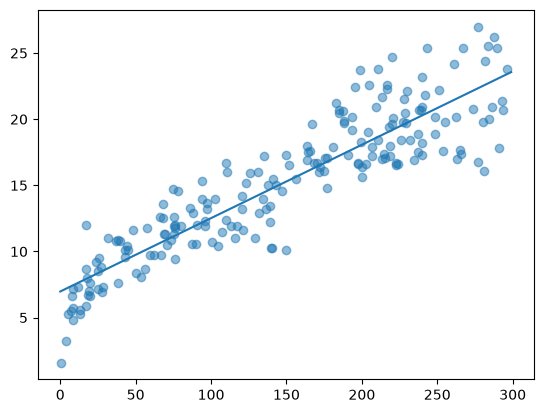

In [ ]:
fig, ax = plt.subplots()

x = df['TV']
x_order = x.sort_values().reset_index(drop=True)

model = reg.intercept_ + reg.coef_ * range(0, 300)

ax.scatter(x, y, alpha=0.5)
ax.plot(model)